In [2]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
with open("models/xgb_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

print("XGBoost model loaded.")

XGBoost model loaded.


In [4]:
labelled = pd.read_csv("processed_data/labelled_large.csv")

print(labelled.shape)

(941531, 15)


In [5]:
feature_cols = [
    "h_dist_nm",
    "v_dist_ft",
    "closing_rate_nm_s",
    "bearing_diff",
    "time_to_cpa_s"
]

X = labelled[feature_cols].fillna(0)

print(X.shape)

(941531, 5)


In [6]:
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer ready.")

SHAP explainer ready.


In [7]:
sample = X.sample(
    n=5000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

print("SHAP values computed.")

SHAP values computed.


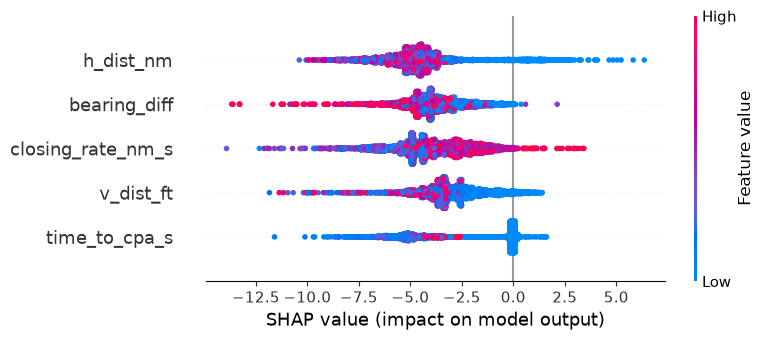

Summary plot saved.


In [8]:
import os

os.makedirs("../results", exist_ok=True)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Summary plot saved.")

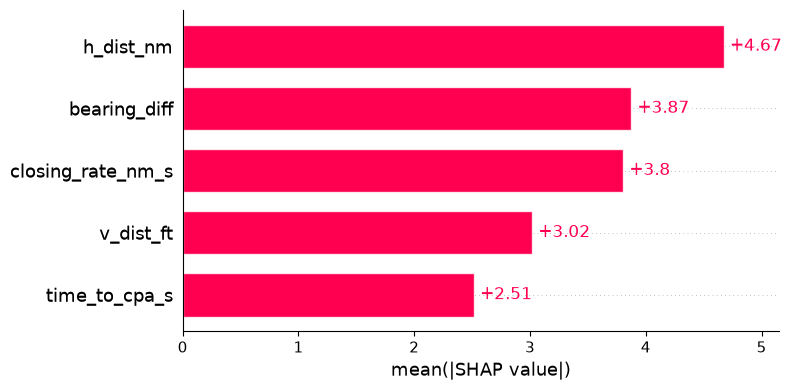

Feature importance plot saved.


In [9]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values,
        data=sample.values,
        feature_names=sample.columns
    ),
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance plot saved.")

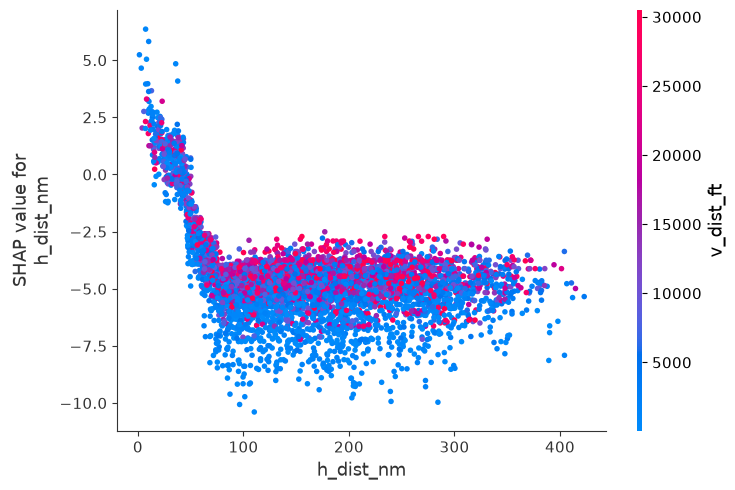

In [10]:
shap.dependence_plot(
    "h_dist_nm",
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/shap_dependence_hdist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

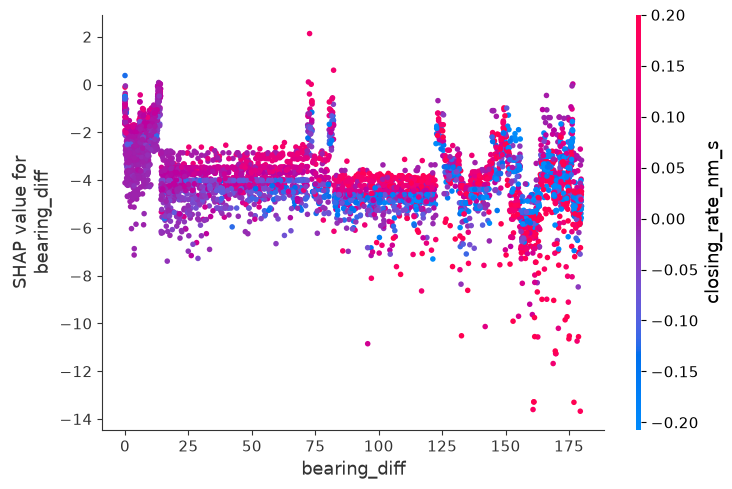

Bearing dependence plot saved.


In [12]:
shap.dependence_plot(
    "bearing_diff",
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/shap_dependence_bearing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bearing dependence plot saved.")

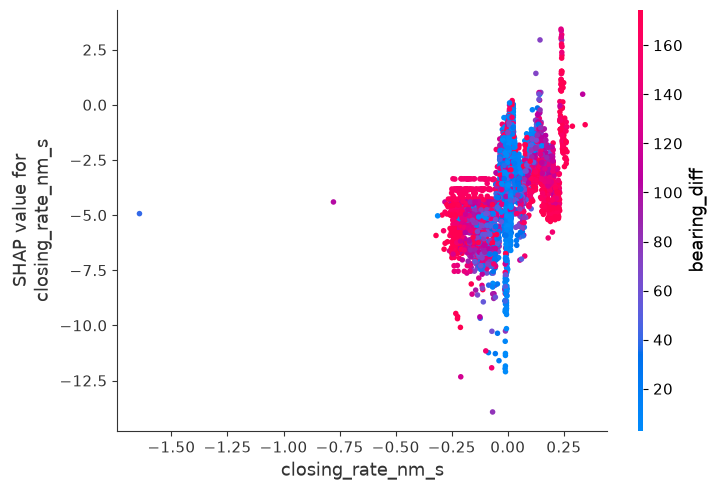

Closing-rate dependence plot saved.


In [13]:
shap.dependence_plot(
    "closing_rate_nm_s",
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/shap_dependence_closing_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Closing-rate dependence plot saved.")

In [1]:
python scripts/07_phase_features.py

SyntaxError: invalid decimal literal (1403692550.py, line 1)

In [ ]:
python scripts/07_phase_features.py